2026-03-08 15:26:15,719 | INFO | DEVICE: cuda
2026-03-08 15:26:15,720 | INFO | OUT_DIR: gru_amzn_baseline_only_20260308_152615
2026-03-08 15:26:15,721 | INFO | BASE_PARAMS: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.3, 'dense_size': 32, 'batch_size': 32, 'lr': 0.001, 'weight_decay': 1e-05, 'huber_delta': 1.0, 'clip_grad': 0.5}
2026-03-08 15:26:15,738 | INFO | Data shape after dropna: (4028, 25)
2026-03-08 15:26:15,739 | INFO | Using 23 features
2026-03-08 15:26:15,740 | INFO | Features: ['Close+T1X2B1:WB1:Y1', 'High', 'Low', 'Open', 'Volume', 'ret_1', 'ret_2', 'ret_3', 'ret_4', 'ret_5', 'sma_10', 'sma_20', 'ma_gap_10', 'ma_gap_20', 'range_pct', 'vol_10', 'vol_20', 'vol_chg', 'vol_sma_20', 'vol_ratio_20', 'co_ret', 'upper_wick', 'lower_wick']
2026-03-08 15:26:15,741 | INFO | Train size: 2819
2026-03-08 15:26:15,741 | INFO | Val size:   604
2026-03-08 15:26:15,742 | INFO | Test size:  605
2026-03-08 15:26:15,743 | INFO | Train dates: 2010-02-02 00:00:00 -> 2021-04-14 00:00:00
202


=== FINAL TEST RESULT ===
Baseline params          : {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.3, 'dense_size': 32, 'batch_size': 32, 'lr': 0.001, 'weight_decay': 1e-05, 'huber_delta': 1.0, 'clip_grad': 0.5}
Best epoch               : 14
Test loss                : 0.368744
Test RMSE                : 0.019809
Test MAE                 : 0.014258
Test R2                  : -0.000111
Test Direction Acc       : 0.5240
Pred std                 : 0.000149
True std                 : 0.019808
Std ratio                : 0.0075


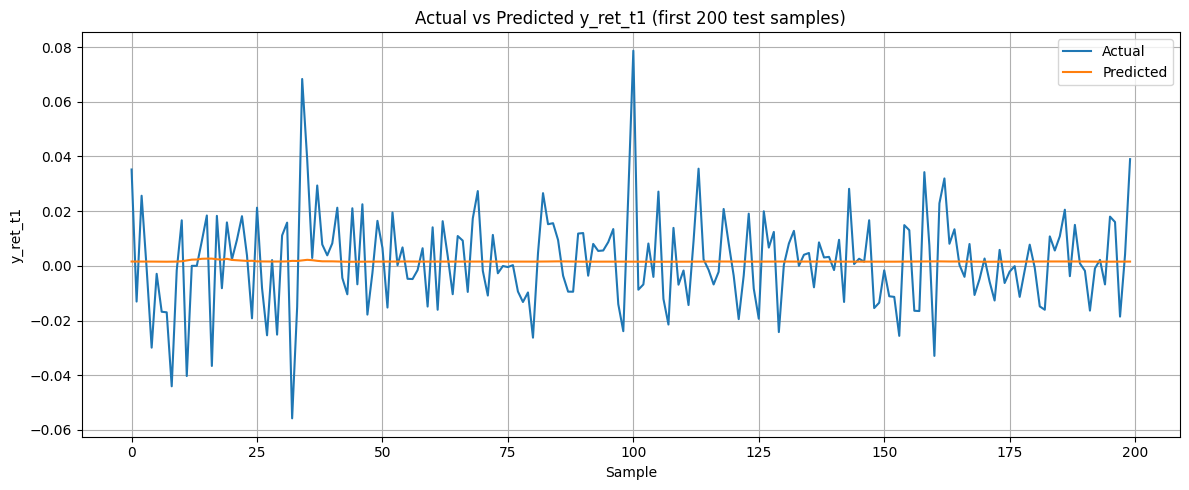

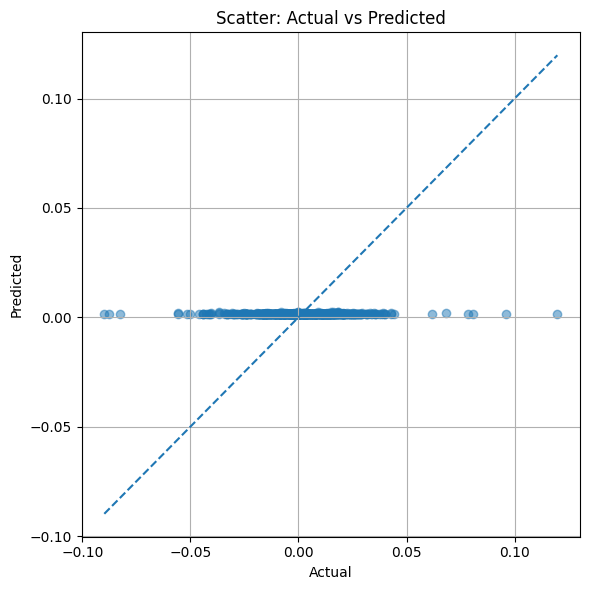

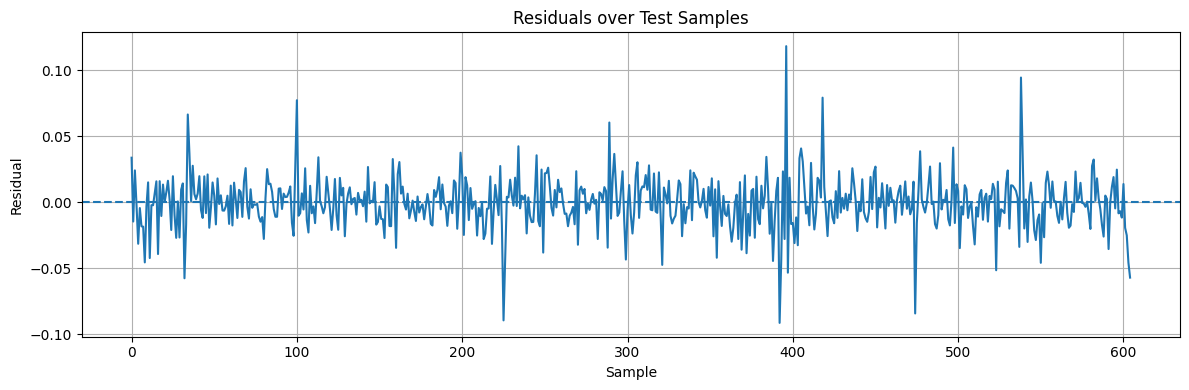

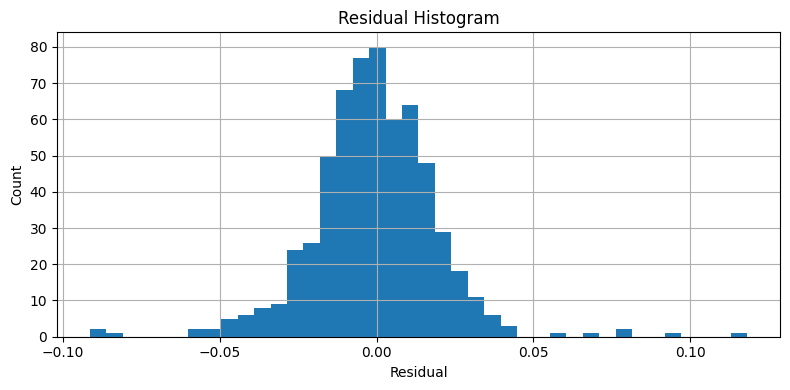

2026-03-08 15:26:25,642 | INFO | All done.


In [11]:
import os
import copy
import math
import json
import random
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1) CONFIG
# ============================================================
CSV_PATH = "../SnP_daily_update_AMZN_features_with_target.csv"

DATE_COL = "Date"
TARGET_COL = "y_ret_t1"

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

SEQ_LEN = 7
FULL_EPOCHS = 120
PATIENCE = 12
MIN_DELTA = 1e-5

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_PARAMS = {
    "hidden_size": 256,
    "num_layers": 2,
    "dropout": 0.3,
    "dense_size": 32,
    "batch_size": 32,
    "lr": 0.001,
    "weight_decay": 1e-5,
    "huber_delta": 1.0,
    "clip_grad": 0.5
}

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = f"gru_amzn_baseline_only_{RUN_TS}"
LOG_DIR = os.path.join(OUT_DIR, "logs")
MODEL_DIR = os.path.join(OUT_DIR, "models")
PLOT_DIR = os.path.join(OUT_DIR, "plots")
RESULT_DIR = os.path.join(OUT_DIR, "results")

for d in [OUT_DIR, LOG_DIR, MODEL_DIR, PLOT_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)


# ============================================================
# 2) LOGGER
# ============================================================
def build_logger(log_path: str, logger_name: str):
    logger = logging.getLogger(logger_name)
    logger.setLevel(logging.INFO)

    if logger.hasHandlers():
        logger.handlers.clear()

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")

    fh = logging.FileHandler(log_path, encoding="utf-8")
    fh.setLevel(logging.INFO)
    fh.setFormatter(fmt)

    sh = logging.StreamHandler()
    sh.setLevel(logging.INFO)
    sh.setFormatter(fmt)

    logger.addHandler(fh)
    logger.addHandler(sh)
    return logger


main_log_path = os.path.join(LOG_DIR, "main.log")
logger = build_logger(main_log_path, "gru_main")


# ============================================================
# 3) SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)
logger.info(f"DEVICE: {DEVICE}")
logger.info(f"OUT_DIR: {OUT_DIR}")
logger.info(f"BASE_PARAMS: {BASE_PARAMS}")


# ============================================================
# 4) LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.sort_values(DATE_COL).reset_index(drop=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
FEATURE_COLS = [c for c in numeric_cols if c != TARGET_COL]

use_cols = [DATE_COL] + FEATURE_COLS + [TARGET_COL]
df = df[use_cols].copy().dropna().reset_index(drop=True)

logger.info(f"Data shape after dropna: {df.shape}")
logger.info(f"Using {len(FEATURE_COLS)} features")
logger.info(f"Features: {FEATURE_COLS}")


# ============================================================
# 5) TIME SPLIT
# ============================================================
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

logger.info(f"Train size: {len(train_df)}")
logger.info(f"Val size:   {len(val_df)}")
logger.info(f"Test size:  {len(test_df)}")

logger.info(f"Train dates: {train_df[DATE_COL].min()} -> {train_df[DATE_COL].max()}")
logger.info(f"Val dates:   {val_df[DATE_COL].min()} -> {val_df[DATE_COL].max()}")
logger.info(f"Test dates:  {test_df[DATE_COL].min()} -> {test_df[DATE_COL].max()}")


# ============================================================
# 6) FEATURE CLIP USING TRAIN QUANTILES
# ============================================================
feature_clip_info = {}

for col in FEATURE_COLS:
    low = train_df[col].quantile(0.01)
    high = train_df[col].quantile(0.99)
    feature_clip_info[col] = {"low": float(low), "high": float(high)}

    train_df[col] = train_df[col].clip(low, high)
    val_df[col]   = val_df[col].clip(low, high)
    test_df[col]  = test_df[col].clip(low, high)

with open(os.path.join(RESULT_DIR, "feature_clip_info.json"), "w", encoding="utf-8") as f:
    json.dump(feature_clip_info, f, indent=2)


# ============================================================
# 7) SCALE
# ============================================================
x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(train_df[FEATURE_COLS])
val_x   = x_scaler.transform(val_df[FEATURE_COLS])
test_x  = x_scaler.transform(test_df[FEATURE_COLS])

train_y = y_scaler.fit_transform(train_df[[TARGET_COL]])
val_y   = y_scaler.transform(val_df[[TARGET_COL]])
test_y  = y_scaler.transform(test_df[[TARGET_COL]])

with open(os.path.join(RESULT_DIR, "scaler_info.json"), "w", encoding="utf-8") as f:
    json.dump({
        "x_mean": x_scaler.mean_.tolist(),
        "x_scale": x_scaler.scale_.tolist(),
        "y_mean": y_scaler.mean_.tolist(),
        "y_scale": y_scaler.scale_.tolist(),
        "feature_cols": FEATURE_COLS
    }, f, indent=2)


# ============================================================
# 8) SEQUENCE BUILDING
# ============================================================
def create_sequences_block(x_block, y_block, seq_len):
    xs, ys = [], []
    for i in range(seq_len, len(x_block)):
        xs.append(x_block[i-seq_len:i])
        ys.append(y_block[i])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

def create_sequences_with_context(prev_x, cur_x, cur_y, seq_len):
    combo_x = np.vstack([prev_x, cur_x])

    xs, ys = [], []
    prev_len = len(prev_x)

    for j in range(len(cur_x)):
        combo_idx = prev_len + j
        start = combo_idx - seq_len
        if start < 0:
            continue
        x_seq = combo_x[start:combo_idx]
        if len(x_seq) == seq_len:
            xs.append(x_seq)
            ys.append(cur_y[j])

    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train, y_train = create_sequences_block(train_x, train_y, SEQ_LEN)
X_val, y_val = create_sequences_with_context(train_x[-SEQ_LEN:], val_x, val_y, SEQ_LEN)
X_test, y_test = create_sequences_with_context(val_x[-SEQ_LEN:], test_x, test_y, SEQ_LEN)

logger.info(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
logger.info(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
logger.info(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")


# ============================================================
# 9) DATASET
# ============================================================
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================================================
# 10) MODEL
# ============================================================
class GRURegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=256,
        num_layers=2,
        dropout=0.3,
        dense_size=32
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        self.norm = nn.LayerNorm(hidden_size)

        hidden_dense = max(dense_size // 2, 8)

        self.head = nn.Sequential(
            nn.Linear(hidden_size, dense_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_size, hidden_dense),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dense, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        last_out = out[:, -1, :]
        last_out = self.norm(last_out)
        pred = self.head(last_out)
        return pred


# ============================================================
# 11) METRICS
# ============================================================
def regression_metrics(y_true_scaled, y_pred_scaled, y_scaler):
    y_true = y_scaler.inverse_transform(y_true_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    direction_acc = float(
        np.mean(np.sign(y_true.flatten()) == np.sign(y_pred.flatten()))
    )

    pred_std = float(np.std(y_pred))
    true_std = float(np.std(y_true))
    std_ratio = float(pred_std / (true_std + 1e-12))

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "direction_acc": direction_acc,
        "pred_std": pred_std,
        "true_std": true_std,
        "std_ratio": std_ratio
    }


# ============================================================
# 12) RUN EPOCH
# ============================================================
def run_epoch(model, loader, criterion, optimizer=None, clip_grad=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    preds_all = []
    trues_all = []

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            pred = model(xb)
            loss = criterion(pred, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()

                if clip_grad is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds_all.append(pred.detach().cpu().numpy())
            trues_all.append(yb.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds_all = np.vstack(preds_all)
    trues_all = np.vstack(trues_all)

    return avg_loss, preds_all, trues_all


# ============================================================
# 13) TRAIN BASELINE
# ============================================================
def train_baseline_model(
    params,
    X_train, y_train,
    X_val, y_val,
    y_scaler,
    max_epochs,
    patience=10,
    min_delta=1e-5
):
    train_ds = SequenceDataset(X_train, y_train)
    val_ds   = SequenceDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False)

    model = GRURegressor(
        input_size=len(FEATURE_COLS),
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        dense_size=params["dense_size"]
    ).to(DEVICE)

    criterion = nn.HuberLoss(delta=params["huber_delta"])
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_val_r2 = -float("inf")
    best_val_loss = float("inf")
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())
    bad_epochs = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss, train_pred, train_true = run_epoch(
            model, train_loader, criterion, optimizer, clip_grad=params["clip_grad"]
        )
        val_loss, val_pred, val_true = run_epoch(
            model, val_loader, criterion, optimizer=None, clip_grad=None
        )

        scheduler.step(val_loss)

        train_m = regression_metrics(train_true, train_pred, y_scaler)
        val_m = regression_metrics(val_true, val_pred, y_scaler)
        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "lr": current_lr,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_rmse": train_m["rmse"],
            "train_mae": train_m["mae"],
            "train_r2": train_m["r2"],
            "train_direction_acc": train_m["direction_acc"],
            "val_rmse": val_m["rmse"],
            "val_mae": val_m["mae"],
            "val_r2": val_m["r2"],
            "val_direction_acc": val_m["direction_acc"],
            "val_pred_std": val_m["pred_std"],
            "val_true_std": val_m["true_std"],
            "val_std_ratio": val_m["std_ratio"]
        }
        history.append(row)

        logger.info(
            f"Epoch {epoch:03d} | "
            f"lr={current_lr:.6g} | "
            f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | "
            f"train_rmse={train_m['rmse']:.6f} | val_rmse={val_m['rmse']:.6f} | "
            f"train_r2={train_m['r2']:.6f} | val_r2={val_m['r2']:.6f} | "
            f"train_dir={train_m['direction_acc']:.4f} | val_dir={val_m['direction_acc']:.4f} | "
            f"val_std_ratio={val_m['std_ratio']:.4f}"
        )

        improved = False
        if val_m["r2"] > (best_val_r2 + min_delta):
            improved = True
        elif abs(val_m["r2"] - best_val_r2) <= min_delta and val_loss < best_val_loss:
            improved = True

        if improved:
            best_val_r2 = val_m["r2"]
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            logger.info(f"Early stopping triggered at epoch {epoch}")
            break

    model.load_state_dict(best_state)

    hist_df = pd.DataFrame(history)
    hist_csv = os.path.join(RESULT_DIR, "baseline_history.csv")
    hist_df.to_csv(hist_csv, index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Huber Loss")
    plt.title("Baseline Training Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "baseline_loss.png"))
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(hist_df["epoch"], hist_df["train_r2"], label="Train R2")
    plt.plot(hist_df["epoch"], hist_df["val_r2"], label="Val R2")
    plt.xlabel("Epoch")
    plt.ylabel("R2")
    plt.title("Baseline Training R2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "baseline_r2.png"))
    plt.close()

    model_path = os.path.join(MODEL_DIR, "baseline_best.pt")
    torch.save({
        "params": params,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_r2": best_val_r2,
        "model_state_dict": best_state,
        "feature_cols": FEATURE_COLS,
        "seq_len": SEQ_LEN
    }, model_path)

    best_idx = hist_df["val_r2"].idxmax()

    summary = {
        "best_epoch": int(best_epoch),
        "best_val_loss": float(best_val_loss),
        "best_val_rmse": float(hist_df.loc[best_idx, "val_rmse"]),
        "best_val_mae": float(hist_df.loc[best_idx, "val_mae"]),
        "best_val_r2": float(hist_df.loc[best_idx, "val_r2"]),
        "best_val_direction_acc": float(hist_df.loc[best_idx, "val_direction_acc"]),
        "best_val_pred_std": float(hist_df.loc[best_idx, "val_pred_std"]),
        "best_val_true_std": float(hist_df.loc[best_idx, "val_true_std"]),
        "best_val_std_ratio": float(hist_df.loc[best_idx, "val_std_ratio"]),
        "history_csv": hist_csv,
        "model_path": model_path
    }

    return model, summary


# ============================================================
# 14) TRAIN BASELINE ONLY
# ============================================================
final_model, final_result = train_baseline_model(
    params=BASE_PARAMS,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    y_scaler=y_scaler,
    max_epochs=FULL_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA
)

final_result_df = pd.DataFrame([final_result])
final_result_csv = os.path.join(RESULT_DIR, "baseline_result.csv")
final_result_df.to_csv(final_result_csv, index=False)


# ============================================================
# 15) TEST EVALUATION
# ============================================================
test_ds = SequenceDataset(X_test, y_test)
test_loader = DataLoader(test_ds, batch_size=BASE_PARAMS["batch_size"], shuffle=False)

criterion = nn.HuberLoss(delta=BASE_PARAMS["huber_delta"])
test_loss, test_pred_scaled, test_true_scaled = run_epoch(
    final_model, test_loader, criterion, optimizer=None, clip_grad=None
)

test_metrics = regression_metrics(test_true_scaled, test_pred_scaled, y_scaler)

print("\n=== FINAL TEST RESULT ===")
print(f"Baseline params          : {BASE_PARAMS}")
print(f"Best epoch               : {final_result['best_epoch']}")
print(f"Test loss                : {test_loss:.6f}")
print(f"Test RMSE                : {test_metrics['rmse']:.6f}")
print(f"Test MAE                 : {test_metrics['mae']:.6f}")
print(f"Test R2                  : {test_metrics['r2']:.6f}")
print(f"Test Direction Acc       : {test_metrics['direction_acc']:.4f}")
print(f"Pred std                 : {test_metrics['pred_std']:.6f}")
print(f"True std                 : {test_metrics['true_std']:.6f}")
print(f"Std ratio                : {test_metrics['std_ratio']:.4f}")

logger.info("=" * 90)
logger.info("FINAL TEST RESULT")
logger.info(f"Baseline params: {BASE_PARAMS}")
logger.info(f"Best epoch: {final_result['best_epoch']}")
logger.info(f"Test loss: {test_loss:.6f}")
logger.info(f"Test RMSE: {test_metrics['rmse']:.6f}")
logger.info(f"Test MAE : {test_metrics['mae']:.6f}")
logger.info(f"Test R2  : {test_metrics['r2']:.6f}")
logger.info(f"Test Direction Acc: {test_metrics['direction_acc']:.4f}")
logger.info(f"Pred std: {test_metrics['pred_std']:.6f}")
logger.info(f"True std: {test_metrics['true_std']:.6f}")
logger.info(f"Std ratio: {test_metrics['std_ratio']:.4f}")


# ============================================================
# 16) SAVE PREDICTIONS
# ============================================================
test_pred = y_scaler.inverse_transform(test_pred_scaled).flatten()
test_true = y_scaler.inverse_transform(test_true_scaled).flatten()

pred_df = pd.DataFrame({
    "Actual_y_ret_t1": test_true,
    "Predicted_y_ret_t1": test_pred
})

pred_csv = os.path.join(RESULT_DIR, "test_predictions.csv")
pred_df.to_csv(pred_csv, index=False)


# ============================================================
# 17) PLOTS
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(pred_df["Actual_y_ret_t1"].values[:200], label="Actual")
plt.plot(pred_df["Predicted_y_ret_t1"].values[:200], label="Predicted")
plt.title("Actual vs Predicted y_ret_t1 (first 200 test samples)")
plt.xlabel("Sample")
plt.ylabel("y_ret_t1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "test_actual_vs_pred.png"))
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(pred_df["Actual_y_ret_t1"], pred_df["Predicted_y_ret_t1"], alpha=0.5)
mn = min(pred_df["Actual_y_ret_t1"].min(), pred_df["Predicted_y_ret_t1"].min())
mx = max(pred_df["Actual_y_ret_t1"].max(), pred_df["Predicted_y_ret_t1"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Scatter: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "scatter_actual_vs_pred.png"))
plt.show()

residuals = pred_df["Actual_y_ret_t1"] - pred_df["Predicted_y_ret_t1"]
plt.figure(figsize=(12, 4))
plt.plot(residuals.values)
plt.axhline(0, linestyle="--")
plt.title("Residuals over Test Samples")
plt.xlabel("Sample")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "residual_over_time.png"))
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(residuals.values, bins=40)
plt.title("Residual Histogram")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "residual_hist.png"))
plt.show()


# ============================================================
# 18) FINAL SUMMARY
# ============================================================
final_summary = {
    "feature_cols": FEATURE_COLS,
    "num_features": len(FEATURE_COLS),
    "seq_len": SEQ_LEN,
    "base_params": BASE_PARAMS,
    "best_epoch": int(final_result["best_epoch"]),
    "baseline_result_csv": final_result_csv,
    "final_model_path": final_result["model_path"],
    "test_loss": float(test_loss),
    "test_rmse": float(test_metrics["rmse"]),
    "test_mae": float(test_metrics["mae"]),
    "test_r2": float(test_metrics["r2"]),
    "test_direction_acc": float(test_metrics["direction_acc"]),
    "test_pred_std": float(test_metrics["pred_std"]),
    "test_true_std": float(test_metrics["true_std"]),
    "test_std_ratio": float(test_metrics["std_ratio"]),
    "test_predictions_csv": pred_csv,
    "main_log_path": main_log_path
}

with open(os.path.join(RESULT_DIR, "final_summary.json"), "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2)

logger.info("All done.")